## Closeness Metric

In [18]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from pathlib import Path
from collections import Counter
 
from gensim.corpora import Dictionary
from gensim.models import LdaModel


In [19]:
# File Paths
BASE = Path("..").resolve()
OUT = BASE / "out"

CS_COURSE_PATH = OUT / "cs_course_skills.jsonl"
IT_COURSE_PATH = OUT / "it_course_skills.jsonl"

CS_LOCAL_JOBS_PATH = OUT / "local_cs_skills.jsonl"
IT_LOCAL_JOBS_PATH = OUT / "local_it_skills.jsonl"

CS_INTL_JOBS_PATH = OUT / "international_cs_skills.jsonl"
IT_INTL_JOBS_PATH = OUT / "international_it_skills.jsonl"

UNRELATED_JOBS_PATH = OUT / "unrelated_skills.jsonl"

AI_JOBS_PATH = OUT / "ai_skills.jsonl"

In [20]:
# Data Loading
for path in [
    CS_COURSE_PATH, IT_COURSE_PATH,
    CS_LOCAL_JOBS_PATH, CS_INTL_JOBS_PATH,
    IT_LOCAL_JOBS_PATH, IT_INTL_JOBS_PATH,
    UNRELATED_JOBS_PATH,
    AI_JOBS_PATH
]:
    if not path.exists():
        raise FileNotFoundError(f"{path} not found.")

cs_course_df = pd.read_json(CS_COURSE_PATH, lines=True)
it_course_df = pd.read_json(IT_COURSE_PATH, lines=True)

cs_local_df = pd.read_json(CS_LOCAL_JOBS_PATH, lines=True)
cs_intl_df = pd.read_json(CS_INTL_JOBS_PATH, lines=True)

it_local_df = pd.read_json(IT_LOCAL_JOBS_PATH, lines=True)
it_intl_df = pd.read_json(IT_INTL_JOBS_PATH, lines=True)

unrelated_df = pd.read_json(UNRELATED_JOBS_PATH, lines=True)
ai_df = pd.read_json(AI_JOBS_PATH, lines=True)


In [21]:
# Data Preparation

def normalize_multiword_skills(skills):
    if not isinstance(skills, list):
        return []
    return [str(skill).strip().replace(" ", "_") for skill in skills if str(skill).strip()]

def clean_tokens(tokens):
    return [
        t for t in tokens
        if t not in {"computer_science", "information_technology"}
    ]

def prepare_texts(df):
    df = df.copy()
    df["skills"] = df["skills"].apply(normalize_multiword_skills)
    texts = df["skills"].tolist()
    texts = [clean_tokens(t) for t in texts]
    texts = [t for t in texts if len(t) > 0]
    return texts

cs_course_texts = prepare_texts(cs_course_df)
it_course_texts = prepare_texts(it_course_df)

cs_local_texts = prepare_texts(cs_local_df)
cs_intl_texts = prepare_texts(cs_intl_df)

it_local_texts = prepare_texts(it_local_df)
it_intl_texts = prepare_texts(it_intl_df)

unrelated_texts = prepare_texts(unrelated_df)
ai_texts = prepare_texts(ai_df)

print("CS Courses:", len(cs_course_texts))
print("IT Courses:", len(it_course_texts))
print("CS Local Jobs:", len(cs_local_texts))
print("CS International Jobs:", len(cs_intl_texts))
print("IT Local Jobs:", len(it_local_texts))
print("IT International Jobs:", len(it_intl_texts))
print("Unrelated Jobs:", len(unrelated_texts))
print("AI Jobs:", len(ai_texts))

CS Courses: 35
IT Courses: 29
CS Local Jobs: 13
CS International Jobs: 1313
IT Local Jobs: 13
IT International Jobs: 1351
Unrelated Jobs: 1628
AI Jobs: 1092


In [22]:
# Optimal Number of Topics per Thematic Area
CS_NUM_TOPICS = 14
IT_NUM_TOPICS = 15

# Function to train LDA with a fixed number of topics
def train_lda(skills, num_topics, no_below=1, no_above=0.95):
    dictionary = Dictionary(skills)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)

    corpus = [dictionary.doc2bow(skill) for skill in skills]

    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        iterations=100
    )

    return {
        "dictionary": dictionary,
        "corpus": corpus,
        "model": model
    }

In [23]:
# Closeness Metric Calculation

# Function to extract topic words and probabilities
def get_topic_word_probs(model, num_topics, num_words=50):
    topics = model.show_topics(num_topics=num_topics, num_words=num_words, formatted=False)
    topic_word_probs = {}

    for topic_id, word_probs in topics:
        topic_word_probs[topic_id] = dict(word_probs)

    return topic_word_probs

# Function to score one document against all topics
def score_document(doc_tokens, topic_word_probs):
    word_counts = Counter(doc_tokens)
    topic_scores = {}

    for topic_id, word_probs in topic_word_probs.items():
        score = 0.0
        for word, prob in word_probs.items():
            if word in word_counts:
                score += word_counts[word] * prob
        topic_scores[topic_id] = score

    best_topic = max(topic_scores, key=topic_scores.get)
    best_score = topic_scores[best_topic]

    return best_score, best_topic, topic_scores

# Function to compute closeness for a dataset
def compute_closeness(texts, topic_word_probs):
    doc_scores = []
    best_topics = []

    for doc in texts:
        best_score, best_topic, _ = score_document(doc, topic_word_probs)
        doc_scores.append(best_score)
        best_topics.append(best_topic)

    closeness = np.mean(doc_scores) if doc_scores else 0.0

    return {
        "closeness": closeness,
        "doc_scores": doc_scores,
        "best_topics": best_topics
    }

In [24]:
def compute_alignment_metric(course_results, intl_results, local_results, unrelated_results, ai_results=None):
    course_closeness = course_results["closeness"]
    intl_closeness = intl_results["closeness"]
    local_closeness = local_results["closeness"]
    unrelated_closeness = unrelated_results["closeness"]
    
    intl_alignment_score = (intl_closeness - unrelated_closeness) / (course_closeness - unrelated_closeness) if (course_closeness - unrelated_closeness) != 0 else 0.0
    local_alignment_score = (local_closeness - unrelated_closeness) / (course_closeness - unrelated_closeness) if (course_closeness - unrelated_closeness) != 0 else 0.0
    ai_alignment_score = None
    if ai_results is not None:
        ai_closeness = ai_results["closeness"]
        ai_alignment_score = (ai_closeness - unrelated_closeness) / (course_closeness - unrelated_closeness) if (course_closeness - unrelated_closeness) != 0 else 0.0
    
    return intl_alignment_score, local_alignment_score, ai_alignment_score

---
# Closeness Metric for Computer Science
---

In [25]:
# Train LDA on CS course syllabi only (not combined with JDs)
cs_lda = train_lda(cs_course_texts, CS_NUM_TOPICS)

print("Computer Science Topics")
cs_topics = cs_lda["model"].print_topics(num_words=10)
for topic_num, topic_words in cs_topics:
    print(f"\nTopic {topic_num}: {topic_words}")

print("\n" + "="*80 + "\n")

Computer Science Topics

Topic 0: 0.011*"e" + 0.008*"programming" + 0.008*"software_design" + 0.008*"idioms" + 0.008*"source_code" + 0.008*"design_patterns" + 0.008*"user_interface" + 0.008*"interactive_systems" + 0.008*"graphical_user_interface" + 0.008*"visual_design"

Topic 1: 0.009*"operations" + 0.009*"programming" + 0.009*"database_system" + 0.009*"sql" + 0.009*"transaction_management" + 0.009*"program_management" + 0.009*"database_model" + 0.009*"database_design" + 0.009*"set_theory" + 0.009*"database_management_system"

Topic 2: 0.011*"case" + 0.011*"e" + 0.006*"teamwork" + 0.006*"system_design" + 0.006*"abstractions" + 0.006*"steady_state" + 0.006*"simulations" + 0.006*"poisson_process" + 0.006*"calibration" + 0.006*"random_variable"

Topic 3: 0.001*"probability" + 0.001*"priority_queue" + 0.001*"programming_language" + 0.001*"random_access" + 0.001*"sorting" + 0.001*"user_defined" + 0.001*"data_structure" + 0.001*"linear_search" + 0.001*"arithmetic" + 0.001*"parameter"

Topic

In [26]:
# Computing Closeness Scores
cs_topic_word_probs = get_topic_word_probs(cs_lda["model"], CS_NUM_TOPICS, num_words=50)

cs_course_results = compute_closeness(cs_course_texts, cs_topic_word_probs)
cs_local_results = compute_closeness(cs_local_texts, cs_topic_word_probs)
cs_intl_results = compute_closeness(cs_intl_texts, cs_topic_word_probs)
cs_ru_results = compute_closeness(unrelated_texts, cs_topic_word_probs)
ai_results = compute_closeness(ai_texts, cs_topic_word_probs)

# Final Alignment Scores
cs_intl_alignment, cs_local_alignment, ai_alignment = compute_alignment_metric(
    cs_course_results, cs_intl_results, cs_local_results, cs_ru_results, ai_results
 )

In [27]:
# Results Compilation
cs_results_df = pd.DataFrame([
    {"Dataset": "CS Courses", "Closeness": cs_course_results["closeness"]},
    {"Dataset": "CS Local Jobs", "Closeness": cs_local_results["closeness"]},
    {"Dataset": "CS International Jobs", "Closeness": cs_intl_results["closeness"]},
    {"Dataset": "AI Jobs", "Closeness": ai_results["closeness"]},
    {"Dataset": "Unrelated Jobs", "Closeness": cs_ru_results["closeness"]}
])

cs_results_df["Closeness"] = cs_results_df["Closeness"].round(4)
cs_results_df

,Dataset,Closeness
0,CS Courses,0.1424
1,CS Local Jobs,0.0138
2,CS International Jobs,0.0191
3,AI Jobs,0.0191
4,Unrelated Jobs,0.0104


In [28]:
# Final Alignment Scores
alignment_df = pd.DataFrame([
    {"Dataset": "CS International Jobs", "Alignment Score": cs_intl_alignment, "Feedback": "Strong Alignment" if cs_intl_alignment > 0.7 else "Moderate Alignment" if cs_intl_alignment > 0.4 else "Weak Alignment"},
    {"Dataset": "CS Local Jobs", "Alignment Score": cs_local_alignment, "Feedback": "Strong Alignment" if cs_local_alignment > 0.7 else "Moderate Alignment" if cs_local_alignment > 0.4 else "Weak Alignment"},
    {"Dataset": "AI Jobs", "Alignment Score": ai_alignment, "Feedback": "Strong Alignment" if ai_alignment is not None and ai_alignment > 0.7 else "Moderate Alignment" if ai_alignment is not None and ai_alignment > 0.4 else "Weak Alignment" if ai_alignment is not None else "N/A"}
 ])

alignment_df["Alignment Score"] = alignment_df["Alignment Score"].round(4)
alignment_df

,Dataset,Alignment Score,Feedback
0,CS International Jobs,0.0660,Weak Alignment
1,CS Local Jobs,0.0260,Weak Alignment
2,AI Jobs,0.0661,Weak Alignment


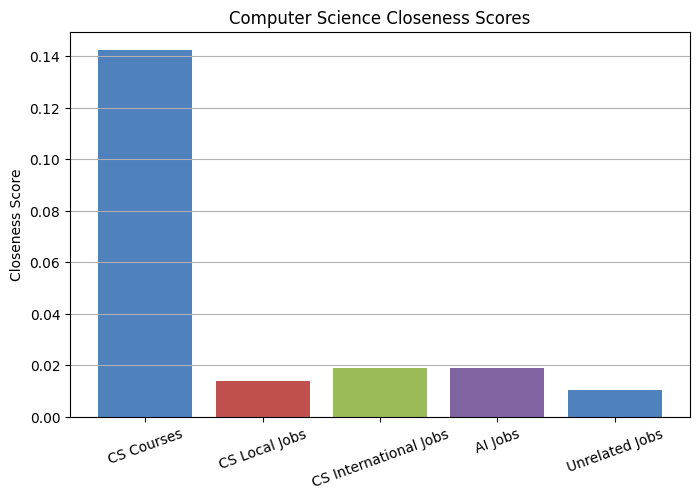

In [29]:
# Bar Chart Visualization
plt.figure(figsize=(8, 5))
plt.bar(cs_results_df["Dataset"], cs_results_df["Closeness"],color=["#4F81BD", "#C0504D", "#9BBB59", "#8064A2"])
plt.ylabel("Closeness Score")
plt.title("Computer Science Closeness Scores")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

---
## Closeness Metric for Information Technology
---

In [30]:
# Train LDA on IT course syllabi
it_combined_texts = it_course_texts + it_local_texts + it_intl_texts
it_lda = train_lda(it_course_texts, IT_NUM_TOPICS)

print("Information Technology Topics")
it_topics = it_lda["model"].print_topics(num_words=10)
for topic_num, topic_words in it_topics:
    print(f"\nTopic {topic_num}: {topic_words}")

print("\n" + "="*80 + "\n")

Information Technology Topics

Topic 0: 0.012*"system_design" + 0.012*"teamwork" + 0.012*"software_engineering" + 0.012*"requirement_analysis" + 0.012*"system_development" + 0.008*"case" + 0.008*"e" + 0.008*"decision_make" + 0.008*"planning" + 0.008*"prototyping"

Topic 1: 0.011*"management" + 0.011*"programming" + 0.011*"server_side" + 0.011*"javascript" + 0.011*"session" + 0.011*"case" + 0.011*"web_programming" + 0.006*"system_architecture" + 0.006*"e" + 0.006*"information_management"

Topic 2: 0.001*"services_support" + 0.001*"services_online" + 0.001*"service_sector" + 0.001*"security_policies" + 0.001*"public_safety" + 0.001*"public_law" + 0.001*"procurement" + 0.001*"process_building" + 0.001*"private_networks" + 0.001*"plan_management"

Topic 3: 0.009*"management" + 0.009*"e" + 0.009*"reliability" + 0.009*"programming" + 0.006*"case" + 0.006*"simd" + 0.006*"mapping" + 0.006*"research" + 0.006*"scalability" + 0.006*"virtual_machine"

Topic 4: 0.010*"user_interface" + 0.005*"commu

In [31]:
# Computing Closeness Scores for IT
it_topic_word_probs = get_topic_word_probs(it_lda["model"], IT_NUM_TOPICS, num_words=50)

it_course_results = compute_closeness(it_course_texts, it_topic_word_probs)
it_local_results = compute_closeness(it_local_texts, it_topic_word_probs)
it_intl_results = compute_closeness(it_intl_texts, it_topic_word_probs)
it_ru_results = compute_closeness(unrelated_texts, it_topic_word_probs)

# Final Alignment Scores for IT
it_intl_alignment, it_local_alignment, _ = compute_alignment_metric(
    it_course_results, it_intl_results, it_local_results, it_ru_results
)

In [32]:
# Results Compilation for IT
it_results_df = pd.DataFrame([
    {"Dataset": "IT Courses", "Closeness": it_course_results["closeness"]},
    {"Dataset": "IT Local Jobs", "Closeness": it_local_results["closeness"]},
    {"Dataset": "IT International Jobs", "Closeness": it_intl_results["closeness"]},
    {"Dataset": "Unrelated Jobs", "Closeness": it_ru_results["closeness"]}
])

it_results_df["Closeness"] = it_results_df["Closeness"].round(4)
it_results_df

,Dataset,Closeness
0,IT Courses,0.1817
1,IT Local Jobs,0.0127
2,IT International Jobs,0.0170
3,Unrelated Jobs,0.0110


In [33]:
# Final Alignment Scores for IT
it_alignment_df = pd.DataFrame([
    {"Dataset": "IT International Jobs", "Alignment Score": it_intl_alignment, "Feedback": "Strong Alignment" if it_intl_alignment > 0.7 else "Moderate Alignment" if it_intl_alignment > 0.4 else "Weak Alignment"},
    {"Dataset": "IT Local Jobs", "Alignment Score": it_local_alignment, "Feedback": "Strong Alignment" if it_local_alignment > 0.7 else "Moderate Alignment" if it_local_alignment > 0.4 else "Weak Alignment"}
])

it_alignment_df["Alignment Score"] = it_alignment_df["Alignment Score"].round(4)
it_alignment_df

,Dataset,Alignment Score,Feedback
0,IT International Jobs,0.0351,Weak Alignment
1,IT Local Jobs,0.0099,Weak Alignment


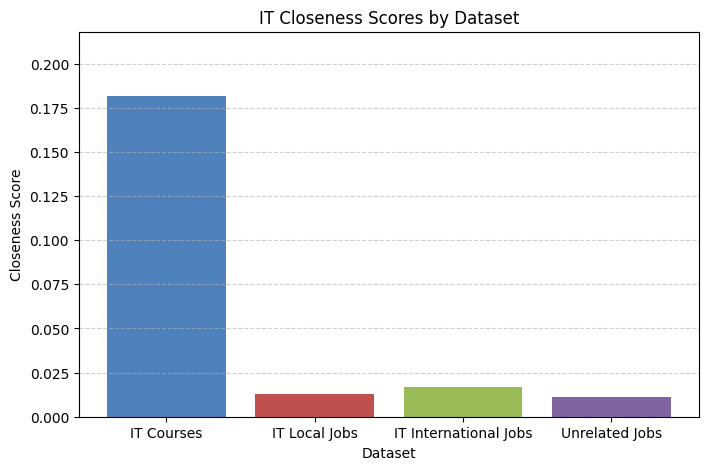

In [34]:
# Bar chart visualization for IT Closeness Scores
plt.figure(figsize=(8, 5))
plt.bar(it_results_df["Dataset"], it_results_df["Closeness"], color=["#4F81BD", "#C0504D", "#9BBB59", "#8064A2"])
plt.title("IT Closeness Scores by Dataset")
plt.ylabel("Closeness Score")
plt.xlabel("Dataset")
plt.ylim(0, it_results_df["Closeness"].max() * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [35]:
n_cs_local = len(cs_local_texts)
n_cs_intl  = len(cs_intl_texts)
n_it_local = len(it_local_texts)
n_it_intl  = len(it_intl_texts)
 
n_total_local = n_cs_local + n_it_local
n_total_intl  = n_cs_intl  + n_it_intl
n_total_all   = n_total_local + n_total_intl
 
rho_w_local = (
    (cs_local_alignment * n_cs_local) + (it_local_alignment * n_it_local)
) / n_total_local if n_total_local > 0 else 0.0
 
rho_w_intl = (
    (cs_intl_alignment * n_cs_intl) + (it_intl_alignment * n_it_intl)
) / n_total_intl if n_total_intl > 0 else 0.0
 
rho_w_overall = (
    (cs_local_alignment * n_cs_local) +
    (cs_intl_alignment  * n_cs_intl)  +
    (it_local_alignment * n_it_local) +
    (it_intl_alignment  * n_it_intl)
) / n_total_all if n_total_all > 0 else 0.0
 
weighted_df = pd.DataFrame([
    {
        "Programme":           "Computer Science",
        "rho Caribbean":       round(cs_local_alignment, 4),
        "rho International":   round(cs_intl_alignment,  4),
        "JD Count (Local)":    n_cs_local,
        "JD Count (Intl)":     n_cs_intl,
    },
    {
        "Programme":           "Information Technology",
        "rho Caribbean":       round(it_local_alignment, 4),
        "rho International":   round(it_intl_alignment,  4),
        "JD Count (Local)":    n_it_local,
        "JD Count (Intl)":     n_it_intl,
    },
    {
        "Programme":           "Weighted rho_w",
        "rho Caribbean":       round(rho_w_local,   4),
        "rho International":   round(rho_w_intl,    4),
        "JD Count (Local)":    n_total_local,
        "JD Count (Intl)":     n_total_intl,
    },
])
 
print("\nWeighted Alignment Scores (rho_w)")
print("=" * 60)
print(weighted_df.to_string(index=False))
print(f"\nOverall weighted rho_w (all regions combined): {rho_w_overall:.4f}")
 


Weighted Alignment Scores (rho_w)
             Programme  rho Caribbean  rho International  JD Count (Local)  JD Count (Intl)
      Computer Science         0.0260             0.0660                13             1313
Information Technology         0.0099             0.0351                13             1351
        Weighted rho_w         0.0180             0.0503                26             2664

Overall weighted rho_w (all regions combined): 0.0500


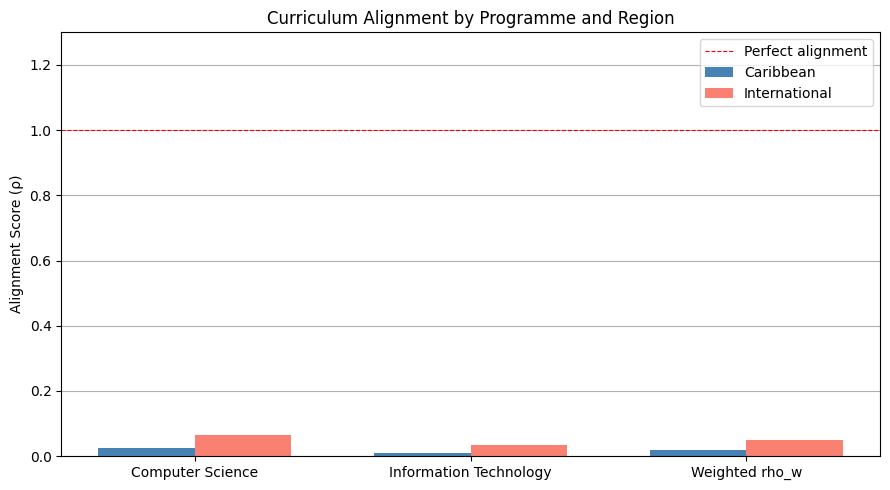

In [36]:
labels    = ["Computer Science", "Information Technology", "Weighted rho_w"]
rho_local = [cs_local_alignment, it_local_alignment, rho_w_local]
rho_intl  = [cs_intl_alignment,  it_intl_alignment,  rho_w_intl]
 
x     = np.arange(len(labels))
width = 0.35
 
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, rho_local, width, label="Caribbean",     color="steelblue")
ax.bar(x + width/2, rho_intl,  width, label="International", color="salmon")
 
ax.axhline(y=1.0, color="red", linestyle="--", linewidth=0.8, label="Perfect alignment")
ax.set_ylabel("Alignment Score (ρ)")
ax.set_title("Curriculum Alignment by Programme and Region")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis="y")
ax.set_ylim(0, 1.3)
plt.tight_layout()
plt.show()